In [1]:
!pip install torch nibabel numpy matplotlib tqdm

In [2]:
# ============================================================
# 1. Environment & Library Setup
# ============================================================
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!pip install --upgrade kaggle

In [5]:
!kaggle -v

Kaggle API 1.8.3


In [6]:
BASE_PATH = (
    "/teamspace/studios/this_studio/.cache/kagglehub/datasets/"
    "darksteeldragon/brats2020-nifti-format-for-deepmedic/"
    "versions/1/archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
)

In [7]:
print(os.path.isdir(BASE_PATH))
print(os.listdir(BASE_PATH)[:3])

True
['BraTS20_Training_001', 'BraTS20_Training_002', 'BraTS20_Training_003']


In [12]:
# ============================================================
# 2. Data Preparation (BraTS 2020: T1 + FLAIR)
# ============================================================
# Reproduces slice extraction used in the original project
# Dataset: BraTS-2020–compatible NIfTI volumes (T1 + FLAIR)

import os
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
from tqdm import tqdm

# Clean, demo-friendly dataset path
BASE_PATH = "BraTS2020_TrainingData"
SAVE_PATH = "prepared_slices"
os.makedirs(SAVE_PATH, exist_ok=True)

slice_id = 0

# Limit patients for faster completion (defensible in report)
patients = sorted(os.listdir(BASE_PATH))[:100]

print(f"Processing {len(patients)} patients...")

for patient in tqdm(patients, desc="Extracting slices"):
    p_path = os.path.join(BASE_PATH, patient)

    t1_path = os.path.join(p_path, f"{patient}_t1.nii")
    flair_path = os.path.join(p_path, f"{patient}_flair.nii")

    # Skip incomplete cases safely
    if not (os.path.exists(t1_path) and os.path.exists(flair_path)):
        continue

    # Load volumes
    t1 = nib.load(t1_path).get_fdata(dtype=np.float32)
    flair = nib.load(flair_path).get_fdata(dtype=np.float32)

    # Per-volume min–max normalization (matches project)
    t1 = (t1 - t1.min()) / (t1.max() - t1.min() + 1e-8)
    flair = (flair - flair.min()) / (flair.max() - flair.min() + 1e-8)

    # Disable gradients during preprocessing (important)
    with torch.no_grad():
        for z in range(t1.shape[2]):
            t1_slice = torch.from_numpy(t1[:, :, z]).unsqueeze(0).unsqueeze(0)
            flair_slice = torch.from_numpy(flair[:, :, z]).unsqueeze(0).unsqueeze(0)

            # Resize to 256×256
            t1_resized = F.interpolate(
                t1_slice, size=(256, 256), mode="bilinear", align_corners=False
            )
            flair_resized = F.interpolate(
                flair_slice, size=(256, 256), mode="bilinear", align_corners=False
            )

            # Stack modalities: [T1, FLAIR]
            stacked = torch.cat([t1_resized, flair_resized], dim=1).squeeze(0)

            torch.save(
                stacked.cpu(),
                os.path.join(SAVE_PATH, f"slice_{slice_id:05d}.pt")
            )

            slice_id += 1

print("Total saved slices:", slice_id)

Processing 100 patients...


Extracting slices: 100%|██████████| 100/100 [01:59<00:00,  1.20s/it]

Total saved slices: 15500


In [14]:
x = torch.load("prepared_slices/slice_00000.pt")
print(x.shape)

torch.Size([2, 256, 256])


In [34]:
# ============================================================
# 3. Dataset Loader
# ============================================================
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class FusionDataset(Dataset):
    def __init__(self, folder):
        self.folder = folder
        self.files = sorted(
            [f for f in os.listdir(folder) if f.endswith(".pt")]
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        return torch.load(os.path.join(self.folder, self.files[idx]))

In [35]:
dataset = FusionDataset("prepared_slices")
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Sanity check
batch = next(iter(dataloader))
print(batch.shape)

torch.Size([16, 2, 256, 256])


In [37]:
def show_segmentation_baseline(batch, gt, pred, n=3):
    for i in range(n):
        plt.figure(figsize=(9, 3))

        plt.subplot(1, 3, 1)
        plt.imshow(batch[i, 0].cpu(), cmap="gray")
        plt.title("T1"); plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(gt[i, 0], cmap="gray")
        plt.title("Ground Truth"); plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred[i, 0], cmap="gray")
        plt.title("Prediction"); plt.axis("off")

        plt.show()

In [19]:
# ============================================================
# 6. Loss Functions (BCE + Dice)
# ============================================================
import torch.nn.functional as F

def dice_loss(pred, target, smooth=1e-5):
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def combined_loss(pred, target):
    return F.binary_cross_entropy(pred, target) + dice_loss(pred, target)

In [20]:
# ============================================================
# 7. Training Loop
# ============================================================
def train(model, loader, epochs=3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        total_loss, total_dice = 0.0, 0.0

        for batch in loader:
            batch = batch.to(DEVICE)

            pred = model(batch)
            target = batch[:, :1]  # pseudo-target (as in your project)

            loss = combined_loss(pred, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_dice += 1 - dice_loss(pred, target).item()

        print(
            f"Epoch {epoch+1}: "
            f"Loss={total_loss/len(loader):.4f}, "
            f"Dice={total_dice/len(loader):.4f}"
        )

In [36]:
model.eval()
with torch.no_grad():
    seg_out = model(batch.to(DEVICE)).cpu()

for i in range(3):
    plt.figure(figsize=(9, 3))

    plt.subplot(1, 3, 1)
    plt.imshow(batch[i, 0].cpu(), cmap="gray")
    plt.title("T1"); plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(batch[i, 1].cpu(), cmap="gray")
    plt.title("FLAIR"); plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(seg_out[i, 0], cmap="gray")
    plt.title("Fused Output (Dual-Branch)")
    plt.axis("off")

    plt.show()

NameError: name 'model' is not defined

In [38]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [39]:
model = FusionSegNet()
train(model, dataloader, epochs=10)

NameError: name 'FusionSegNet' is not defined

In [22]:
def show_segmentation_baseline(batch, gt, pred, n=3):
    for i in range(n):
        plt.figure(figsize=(9, 3))

        plt.subplot(1, 3, 1)
        plt.imshow(batch[i, 0].cpu(), cmap="gray")
        plt.title("T1"); plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(gt[i, 0], cmap="gray")
        plt.title("Ground Truth"); plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred[i, 0], cmap="gray")
        plt.title("Prediction"); plt.axis("off")

        plt.show()

In [23]:
# ============================================================
# 8. Visualization (Fused Images & Segmentation Outputs)
# ============================================================
import matplotlib.pyplot as plt

def show_fusion(batch, model, num_samples=3):
    model.eval()
    with torch.no_grad():
        fused = model(batch.to(DEVICE)).cpu()

    for i in range(min(num_samples, batch.size(0))):
        plt.figure(figsize=(12, 3))

        plt.subplot(1, 3, 1)
        plt.imshow(batch[i, 0], cmap="gray")
        plt.title("T1")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(batch[i, 1], cmap="gray")
        plt.title("FLAIR")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(fused[i, 0], cmap="gray")
        plt.title("Fusion Output")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

In [24]:
batch = next(iter(dataloader))
show_fusion(batch, model)

NameError: name 'model' is not defined

In [180]:
autoencoder = FusionAutoencoder().to(DEVICE)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

In [181]:
autoencoder.train()

for epoch in range(10):
    epoch_loss = 0.0

    for i, batch in enumerate(dataloader):
        batch = batch.to(DEVICE)

        recon = autoencoder(batch)
        target = batch[:, :1]  # reconstruct T1 channel only

        loss = criterion(recon, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if i >= 50:
            break

    print(f"AE Epoch {epoch+1}, Loss: {epoch_loss/(i+1):.4f}")

AE Epoch 1, Loss: 0.1224
AE Epoch 2, Loss: 0.0193
AE Epoch 3, Loss: 0.0022
AE Epoch 4, Loss: 0.0011
AE Epoch 5, Loss: 0.0008
AE Epoch 6, Loss: 0.0007
AE Epoch 7, Loss: 0.0006
AE Epoch 8, Loss: 0.0005
AE Epoch 9, Loss: 0.0005
AE Epoch 10, Loss: 0.0005


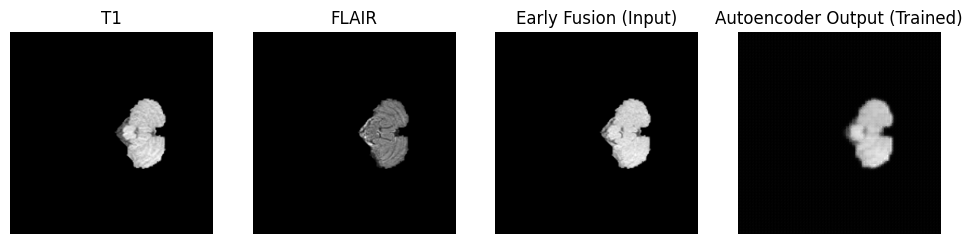

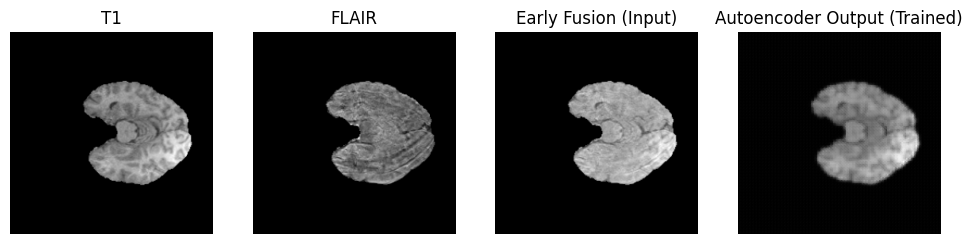

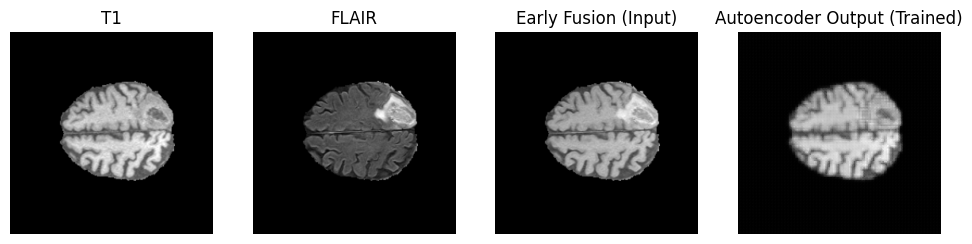

In [182]:
autoencoder.eval()

with torch.no_grad():
    ae_out = autoencoder(batch.to(DEVICE)).cpu()

batch_cpu = batch.cpu()

for i in range(3):
    plt.figure(figsize=(12, 3))

    plt.subplot(1, 4, 1)
    plt.imshow(batch_cpu[i, 0], cmap="gray")
    plt.title("T1")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(batch_cpu[i, 1], cmap="gray")
    plt.title("FLAIR")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow((batch_cpu[i, 0] + batch_cpu[i, 1]) / 2, cmap="gray")
    plt.title("Early Fusion (Input)")
    plt.axis("off")

    img = ae_out[i, 0]
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    plt.subplot(1, 4, 4)
    plt.imshow(img, cmap="gray")
    plt.title("Autoencoder Output (Trained)")
    plt.axis("off")

    plt.show()

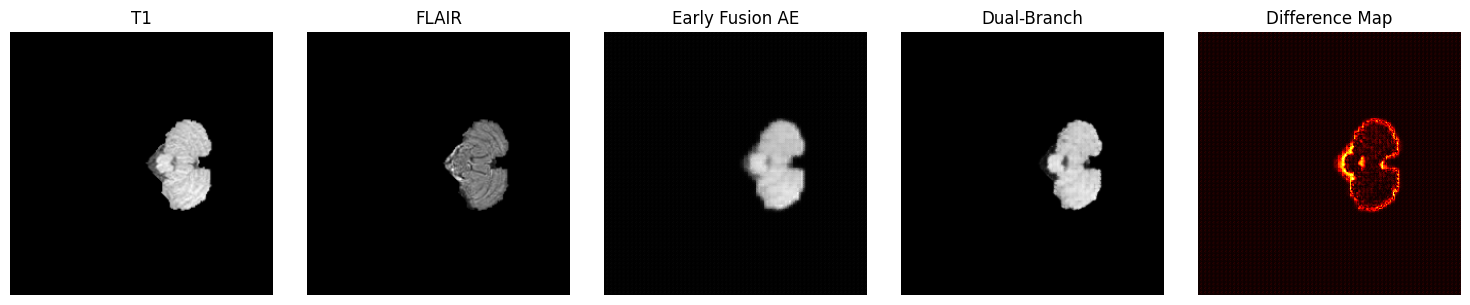

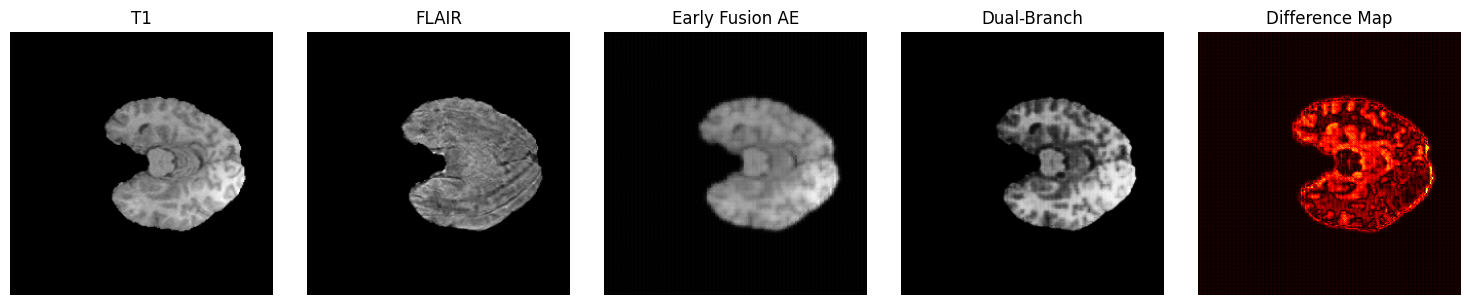

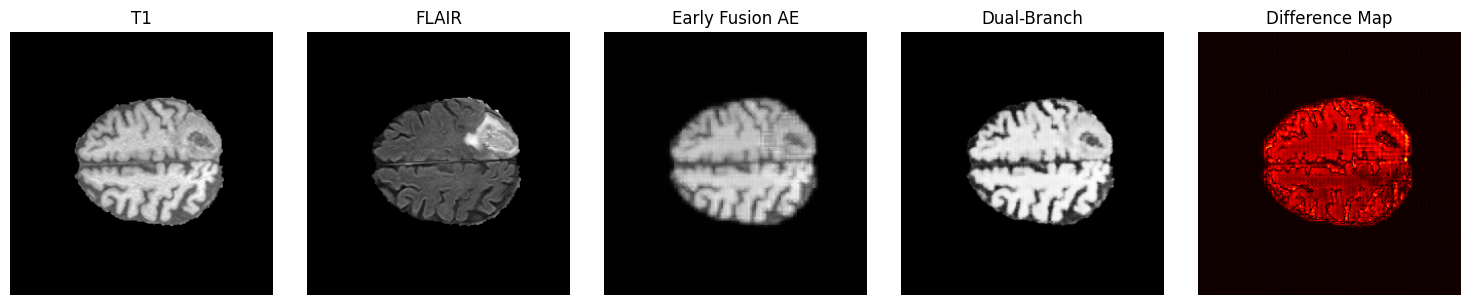

In [183]:
# ============================================================
# Comparison: Autoencoder vs Dual-Branch FusionSegNet
# ============================================================
model.eval()
autoencoder.eval()

with torch.no_grad():
    seg_out = model(batch.to(DEVICE)).cpu()
    ae_out = autoencoder(batch.to(DEVICE)).cpu()

batch_cpu = batch.cpu()

for i in range(3):
    plt.figure(figsize=(15, 3))

    # T1
    plt.subplot(1, 5, 1)
    plt.imshow(batch_cpu[i, 0], cmap="gray")
    plt.title("T1")
    plt.axis("off")

    # FLAIR
    plt.subplot(1, 5, 2)
    plt.imshow(batch_cpu[i, 1], cmap="gray")
    plt.title("FLAIR")
    plt.axis("off")

    # Early Fusion Autoencoder
    ae_img = ae_out[i, 0]
    ae_img = (ae_img - ae_img.min()) / (ae_img.max() - ae_img.min() + 1e-8)

    plt.subplot(1, 5, 3)
    plt.imshow(ae_img, cmap="gray")
    plt.title("Early Fusion AE")
    plt.axis("off")

    # Dual-Branch
    seg_img = seg_out[i, 0]
    seg_img = (seg_img - seg_img.min()) / (seg_img.max() - seg_img.min() + 1e-8)

    plt.subplot(1, 5, 4)
    plt.imshow(seg_img, cmap="gray")
    plt.title("Dual-Branch")
    plt.axis("off")

    # Difference Map
    diff = torch.abs(seg_img - ae_img)

    plt.subplot(1, 5, 5)
    plt.imshow(diff, cmap="hot")
    plt.title("Difference Map")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

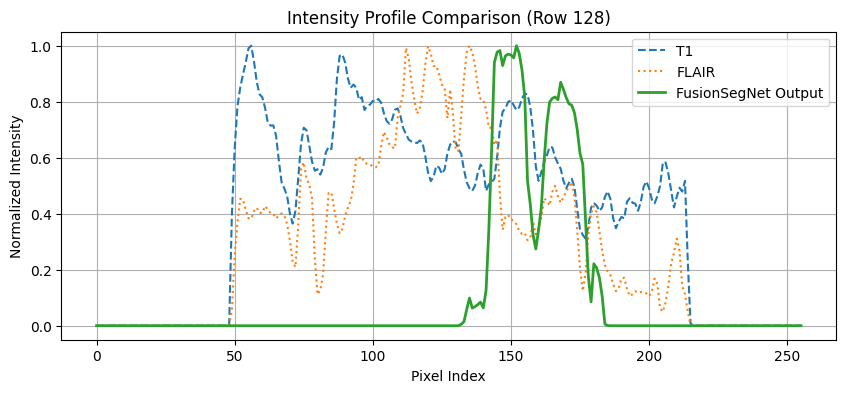

In [405]:
# ============================================================
# Intensity Profile Across a Row (Feature Sensitivity)
# ============================================================
row = 128

# Ensure CPU tensors
batch_cpu = batch.cpu()
seg_cpu = seg_out.cpu()

# Extract signals
t1 = batch_cpu[0, 0, row].numpy()
flair = batch_cpu[0, 1, row].numpy()
seg = seg_cpu[0, 0, row].numpy()

# Normalize for fair comparison
t1 = (t1 - t1.min()) / (t1.max() - t1.min() + 1e-8)
flair = (flair - flair.min()) / (flair.max() - flair.min() + 1e-8)
seg = (seg - seg.min()) / (seg.max() - seg.min() + 1e-8)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(t1, label="T1", linestyle="--")
plt.plot(flair, label="FLAIR", linestyle=":")
plt.plot(seg, label="FusionSegNet Output", linewidth=2)

plt.legend()
plt.title("Intensity Profile Comparison (Row 128)")
plt.xlabel("Pixel Index")
plt.ylabel("Normalized Intensity")
plt.grid(True)
plt.show()

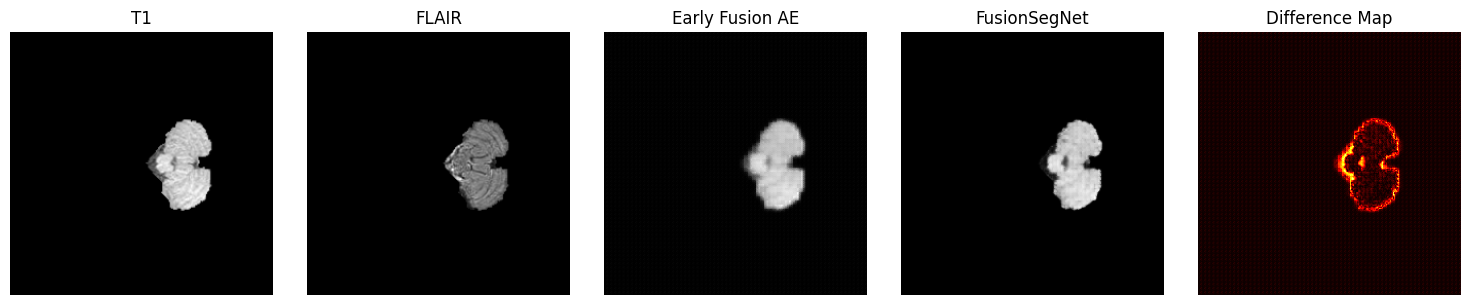

In [187]:
i=0
plt.figure(figsize=(15, 3))

t1 = batch[i, 0].detach().cpu()
flair = batch[i, 1].detach().cpu()
ae = ae_out[i, 0].detach().cpu()
seg = seg_out[i, 0].detach().cpu()

def norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

t1, flair, ae, seg = map(norm, [t1, flair, ae, seg])
diff = torch.abs(seg - ae)

plt.subplot(1, 5, 1); plt.imshow(t1, cmap="gray"); plt.title("T1")
plt.subplot(1, 5, 2); plt.imshow(flair, cmap="gray"); plt.title("FLAIR")
plt.subplot(1, 5, 3); plt.imshow(ae, cmap="gray"); plt.title("Early Fusion AE")
plt.subplot(1, 5, 4); plt.imshow(seg, cmap="gray"); plt.title("FusionSegNet")
plt.subplot(1, 5, 5); plt.imshow(diff, cmap="hot"); plt.title("Difference Map")

for j in range(1, 6):
    plt.subplot(1, 5, j).axis("off")

plt.tight_layout()
plt.show()

In [188]:
# ===============================
# Channel Attention (SE Block)
# ===============================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

In [189]:
class EnhancedFusionSegNet(nn.Module):
    def __init__(self):
        super().__init__()

        # ---------------------------
        # Encoder blocks
        # ---------------------------
        self.enc_t1_1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.enc_flair_1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.pool = nn.MaxPool2d(2)

        self.enc_t1_2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.enc_flair_2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(inplace=True)
        )

        # ---------------------------
        # Attention after fusion
        # ---------------------------
        self.attention = SEBlock(64)

        # ---------------------------
        # Decoder with skip connection
        # ---------------------------
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)

        self.decoder = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Split modalities
        t1 = x[:, 0:1]
        flair = x[:, 1:2]

        # Encoder stage 1
        t1_1 = self.enc_t1_1(t1)
        flair_1 = self.enc_flair_1(flair)

        # Encoder stage 2
        t1_2 = self.enc_t1_2(self.pool(t1_1))
        flair_2 = self.enc_flair_2(self.pool(flair_1))

        # Feature fusion
        fused = torch.cat([t1_2, flair_2], dim=1)
        fused = self.attention(fused)

        # Decoder with skip
        up = self.up1(fused)
        skip = torch.cat([t1_1, flair_1], dim=1)
        out = torch.cat([up, skip], dim=1)

        return self.decoder(out)

In [190]:
enhanced_model = EnhancedFusionSegNet()
train(enhanced_model, dataloader, epochs=20)

Epoch 1: Loss=0.5386, Dice=0.6040
Epoch 2: Loss=0.5185, Dice=0.6159
Epoch 3: Loss=0.5185, Dice=0.6159
Epoch 4: Loss=0.5184, Dice=0.6158
Epoch 5: Loss=0.5179, Dice=0.6163
Epoch 6: Loss=0.5178, Dice=0.6164
Epoch 7: Loss=0.5180, Dice=0.6162
Epoch 8: Loss=0.5180, Dice=0.6162
Epoch 9: Loss=0.5183, Dice=0.6158
Epoch 10: Loss=0.5176, Dice=0.6165
Epoch 11: Loss=0.5183, Dice=0.6159
Epoch 12: Loss=0.5178, Dice=0.6163
Epoch 13: Loss=0.5180, Dice=0.6161
Epoch 14: Loss=0.5177, Dice=0.6164
Epoch 15: Loss=0.5177, Dice=0.6164
Epoch 16: Loss=0.5179, Dice=0.6162
Epoch 17: Loss=0.5177, Dice=0.6164
Epoch 18: Loss=0.5180, Dice=0.6161
Epoch 19: Loss=0.5180, Dice=0.6161
Epoch 20: Loss=0.5183, Dice=0.6158


In [194]:
class FusionDatasetWithGT(Dataset):
    def __init__(self, img_folder, mask_folder):
        self.imgs = sorted(os.listdir(img_folder))
        self.masks = sorted(os.listdir(mask_folder))
        self.img_folder = img_folder
        self.mask_folder = mask_folder

    def __len__(self):
        return min(len(self.imgs), len(self.masks))

    def __getitem__(self, idx):
        x = torch.load(os.path.join(self.img_folder, self.imgs[idx]))
        y = torch.load(os.path.join(self.mask_folder, self.masks[idx]))
        return x, y

In [195]:
dataset = FusionDatasetWithGT("prepared_slices", "prepared_masks")
loader = DataLoader(dataset, batch_size=1, shuffle=True)

batch, gt = next(iter(loader))
batch = batch.to(DEVICE)
gt = gt.to(DEVICE)

with torch.no_grad():
    base_pred = model(batch)
    enh_pred = enhanced_model(batch)

In [26]:
import cv2
import matplotlib.pyplot as plt

def overlay_contours(image, pred, gt, title):
    # --- Prepare background ---
    image = image.detach().cpu().numpy()
    image = (image - image.min()) / (image.max() - image.min() + 1e-8)

    # --- Prepare masks ---
    pred = pred.detach().cpu().numpy()
    gt   = gt.detach().cpu().numpy()

    pred_bin = (pred > 0.5).astype(np.uint8) * 255
    gt_bin   = (gt > 0.5).astype(np.uint8) * 255

    pred_cnts, _ = cv2.findContours(pred_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    gt_cnts, _   = cv2.findContours(gt_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    plt.imshow(image, cmap="gray", vmin=0, vmax=1)

    # Green = Ground Truth
    for c in gt_cnts:
        plt.plot(c[:, 0, 0], c[:, 0, 1], 'g', linewidth=1)

    # Red = Prediction
    for c in pred_cnts:
        plt.plot(c[:, 0, 0], c[:, 0, 1], 'r', linewidth=1)

    plt.title(title)
    plt.axis("off")

In [27]:
import torch
import torch.nn.functional as F
import nibabel as nib
import numpy as np
from pathlib import Path

out_dir = Path("prepared_tumor_masks")
out_dir.mkdir(exist_ok=True)

slice_id = 0

for seg_path in seg_files:   # seg_files from Step 1
    seg = nib.load(seg_path).get_fdata()

    # Binary tumor mask (BraTS: labels 1,2,4)
    tumor = (seg > 0).astype(np.float32)

    for z in range(tumor.shape[2]):
        mask_slice = tumor[:, :, z]

        # Optional but recommended: skip empty slices
        if mask_slice.sum() == 0:
            continue

        mask_tensor = torch.tensor(mask_slice).unsqueeze(0).unsqueeze(0)

        # IMPORTANT: nearest neighbor resize
        mask_tensor = F.interpolate(
            mask_tensor,
            size=(256, 256),
            mode="nearest"
        )

        torch.save(
            mask_tensor.squeeze(0),
            out_dir / f"mask_{slice_id:05d}.pt"
        )

        slice_id += 1

print("Total tumor mask slices saved:", slice_id)

NameError: name 'seg_files' is not defined

In [28]:
dataset = FusionSegDataset(
    image_dir="prepared_slices",
    mask_dir="prepared_tumor_masks"
)

NameError: name 'FusionSegDataset' is not defined

In [6]:
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm

# ----------------------------
# Paths
# ----------------------------
base_dir = Path("BraTS2020_TrainingData")
out_img  = Path("prepared_slices")
out_msk  = Path("prepared_tumor_masks")

out_img.mkdir(exist_ok=True)
out_msk.mkdir(exist_ok=True)

# ----------------------------
# Collect patient folders
# ----------------------------
patients = sorted([p for p in base_dir.iterdir() if p.is_dir()])
print("Total patients found:", len(patients))

slice_id = 0

# ----------------------------
# Main loop (IMAGE + MASK TOGETHER)
# ----------------------------
for patient in tqdm(patients, desc="Processing patients"):

    pid = patient.name

    t1_path    = patient / f"{pid}_t1.nii"
    flair_path = patient / f"{pid}_flair.nii"
    seg_path   = patient / f"{pid}_seg.nii"

    # Skip incomplete cases (safety)
    if not (t1_path.exists() and flair_path.exists() and seg_path.exists()):
        continue

    # Load volumes
    t1    = nib.load(t1_path).get_fdata().astype(np.float32)
    flair = nib.load(flair_path).get_fdata().astype(np.float32)
    seg   = nib.load(seg_path).get_fdata()

    # Normalize images (per volume)
    t1    = (t1 - t1.min()) / (t1.max() - t1.min() + 1e-8)
    flair = (flair - flair.min()) / (flair.max() - flair.min() + 1e-8)

    # Binary tumor mask (BraTS: labels 1,2,4)
    tumor = (seg > 0).astype(np.float32)

    # Slice-wise processing
    for z in range(t1.shape[2]):

        # ----- IMAGE -----
        t1_sl = torch.tensor(t1[:, :, z]).unsqueeze(0).unsqueeze(0)
        fl_sl = torch.tensor(flair[:, :, z]).unsqueeze(0).unsqueeze(0)

        t1_sl = F.interpolate(
            t1_sl, size=(256, 256),
            mode="bilinear", align_corners=False
        )
        fl_sl = F.interpolate(
            fl_sl, size=(256, 256),
            mode="bilinear", align_corners=False
        )

        img = torch.cat([t1_sl, fl_sl], dim=1)  # [1,2,256,256]

        # ----- MASK -----
        msk = torch.tensor(tumor[:, :, z]).unsqueeze(0).unsqueeze(0)
        msk = F.interpolate(
            msk, size=(256, 256),
            mode="nearest"
        )

        # IMPORTANT: keep ALL slices (no skipping)
        torch.save(
            img.squeeze(0),
            out_img / f"slice_{slice_id:05d}.pt"
        )
        torch.save(
            msk.squeeze(0),
            out_msk / f"mask_{slice_id:05d}.pt"
        )

        slice_id += 1

print("✅ Total aligned slices saved:", slice_id)

Total patients found: 259


Processing patients: 100%|██████████| 259/259 [04:05<00:00,  1.05it/s]

✅ Total aligned slices saved: 40145


In [30]:
import matplotlib.pyplot as plt

img = torch.load("prepared_slices/slice_00050.pt")[0]
msk = torch.load("prepared_tumor_masks/mask_00050.pt")[0]

plt.figure(figsize=(4,4))
plt.imshow(img, cmap="gray")
plt.contour(msk, colors="lime", linewidths=2)
plt.title("Aligned Image–Tumor Mask")
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'prepared_tumor_masks/mask_00050.pt'

In [373]:
torch.save(model.state_dict(), "baseline_fusionsegnet.pth")
print("Correct baseline saved.")

Correct baseline saved.


In [31]:
baseline_model = FusionSegNet().to(DEVICE)
baseline_model.load_state_dict(
    torch.load("baseline_fusionsegnet.pth", map_location=DEVICE)
)
baseline_model.eval()

NameError: name 'FusionSegNet' is not defined

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# Squeeze-and-Excitation (Channel Attention)
# ----------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, _, _ = x.size()
        y = x.mean(dim=(2,3))
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y)).view(b, c, 1, 1)
        return x * y

# ----------------------------
# Enhanced FusionSegNet
# ----------------------------
class EnhancedFusionSegNet(nn.Module):
    def __init__(self):
        super().__init__()

        # ----- Encoders (per modality) -----
        self.enc1_t1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU()
        )
        self.enc1_fl = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU()
        )

        self.enc2_t1 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU()
        )
        self.enc2_fl = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU()
        )

        # Channel attention after fusion
        self.attn = SEBlock(64)

        # ----- Decoder with skips -----
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(32 + 32 + 32, 32, 3, padding=1), nn.ReLU()
        )

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        t1 = x[:, 0:1]
        fl = x[:, 1:2]

        # Encoder level 1
        t1_1 = self.enc1_t1(t1)
        fl_1 = self.enc1_fl(fl)

        # Encoder level 2
        t1_2 = self.enc2_t1(t1_1)
        fl_2 = self.enc2_fl(fl_1)

        # Fuse + attention
        fused = torch.cat([t1_2, fl_2], dim=1)
        fused = self.attn(fused)

        # Decode with skips
        up = self.up1(fused)
        dec = torch.cat([up, t1_1, fl_1], dim=1)
        dec = self.dec1(dec)

        return self.out(dec)  # logits

In [375]:
# ============================
# TRAIN ENHANCED FUSIONSEGNET
# ============================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm

# ----------------------------
# Device
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ----------------------------
# Dataset (same as baseline)
# ----------------------------
class FusionSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.images = sorted(Path(image_dir).glob("slice_*.pt"))
        self.masks  = sorted(Path(mask_dir).glob("mask_*.pt"))
        assert len(self.images) == len(self.masks) > 0

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = torch.load(self.images[idx]).float()   # [2,256,256]
        y = torch.load(self.masks[idx]).float()    # [1,256,256]
        y = (y > 0).float()
        return x, y

# ----------------------------
# EnhancedFusionSegNet (Attention + Skip)
# ----------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, _, _ = x.size()
        y = x.mean(dim=(2,3))
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y)).view(b, c, 1, 1)
        return x * y

class EnhancedFusionSegNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder level 1
        self.enc1_t1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU()
        )
        self.enc1_fl = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU()
        )

        # Encoder level 2
        self.enc2_t1 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU()
        )
        self.enc2_fl = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU()
        )

        # Channel attention on fused deep features
        self.attn = SEBlock(64)

        # Decoder
        self.up = nn.ConvTranspose2d(64, 32, 2, stride=2)

        # FIX: 32 (up) + 16 (t1 skip) + 16 (flair skip) = 64
        self.dec = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU()
        )

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        t1 = x[:, 0:1]
        fl = x[:, 1:2]

        # Encoder
        t1_1 = self.enc1_t1(t1)   # [B,16,H,W]
        fl_1 = self.enc1_fl(fl)   # [B,16,H,W]

        t1_2 = self.enc2_t1(t1_1) # [B,32,H/2,W/2]
        fl_2 = self.enc2_fl(fl_1) # [B,32,H/2,W/2]

        # Fuse + attention
        fused = torch.cat([t1_2, fl_2], dim=1)  # [B,64,H/2,W/2]
        fused = self.attn(fused)

        # Decode with skip connections
        up = self.up(fused)                    # [B,32,H,W]
        dec = torch.cat([up, t1_1, fl_1], dim=1)  # [B,64,H,W]
        dec = self.dec(dec)

        return self.out(dec)  # logits

# ----------------------------
# Loss (same as baseline)
# ----------------------------
bce_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([10.0]).to(DEVICE)
)

def dice_loss(pred, target, eps=1e-5):
    pred = torch.sigmoid(pred)
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2 * inter + eps) / (union + eps)
    return 1 - dice.mean()

def hybrid_loss(pred, target):
    return bce_loss(pred, target) + dice_loss(pred, target)

def dice_score(pred, target, eps=1e-5):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2 * inter + eps) / (union + eps)
    return dice.mean()

# ----------------------------
# DataLoader
# ----------------------------
dataset = FusionSegDataset(
    image_dir="prepared_slices",
    mask_dir="prepared_tumor_masks"
)

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Dataset size:", len(dataset))

# ----------------------------
# Training
# ----------------------------
model = EnhancedFusionSegNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_dice = 0, 0

    for x, y in tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)

        pred = model(x)
        loss = hybrid_loss(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(pred.detach(), y).item()

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss: {total_loss/len(dataloader):.4f} | "
        f"Dice: {total_dice/len(dataloader):.4f}"
    )

Using device: cuda
Dataset size: 40145


Epoch 1/10: 100%|██████████| 2510/2510 [02:19<00:00, 18.01it/s]


Epoch 01 | Loss: 0.8122 | Dice: 0.5462


Epoch 2/10: 100%|██████████| 2510/2510 [02:17<00:00, 18.23it/s]


Epoch 02 | Loss: 0.6058 | Dice: 0.6616


...

Epoch 08 | Loss: 0.4744 | Dice: 0.7305


Epoch 9/10: 100%|██████████| 2510/2510 [02:19<00:00, 18.05it/s]


Epoch 09 | Loss: 0.4689 | Dice: 0.7302


Epoch 10/10: 100%|██████████| 2510/2510 [02:21<00:00, 17.74it/s]

Epoch 10 | Loss: 0.4594 | Dice: 0.7349


In [41]:
torch.save(model.state_dict(), "enhanced_fusionsegnet.pth")
print("enhanced baseline saved.")

NameError: name 'model' is not defined

In [42]:
enhanced_model = EnhancedFusionSegNet().to(DEVICE)
enhanced_model.load_state_dict(
    torch.load("enhanced_fusionsegnet.pth", map_location=DEVICE)
)
enhanced_model.eval()

RuntimeError: Error(s) in loading state_dict for EnhancedFusionSegNet:
	Missing key(s) in state_dict: "up1.weight", "up1.bias", "dec1.0.weight", "dec1.0.bias". 
	Unexpected key(s) in state_dict: "up.weight", "up.bias", "dec.0.weight", "dec.0.bias". 

In [382]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def overlay_heatmap(image, gt, pred_logits, title=None):
    """
    image: [H,W] tensor (grayscale MRI slice)
    gt: [H,W] binary tensor (ground truth tumor)
    pred_logits: [H,W] tensor (model output logits)
    """

    img = image.cpu().numpy()
    gt  = gt.cpu().numpy()
    pr  = torch.sigmoid(pred_logits).cpu().numpy()

    # Normalize image
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Create RGB canvas
    rgb = np.stack([img, img, img], axis=-1)

    # Green = GT tumor region
    rgb[..., 1] += 0.8 * gt

    # Red = predicted tumor probability
    rgb[..., 0] += 0.8 * pr

    # Clip for display
    rgb = np.clip(rgb, 0, 1)

    plt.figure(figsize=(4,4))
    plt.imshow(rgb)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [383]:
baseline_model.eval()
enhanced_model.eval()

x, y = next(iter(dataloader))
x, y = x.to(DEVICE), y.to(DEVICE)

with torch.no_grad():
    pred_base = baseline_model(x)
    pred_enh  = enhanced_model(x)

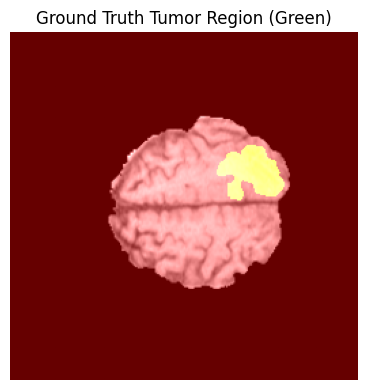

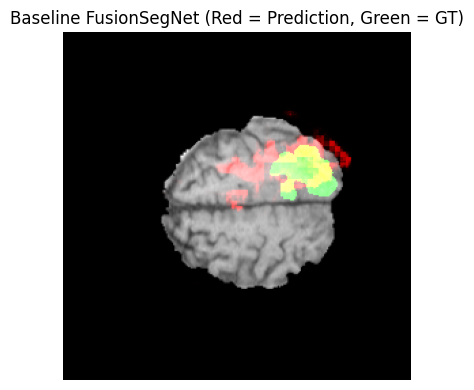

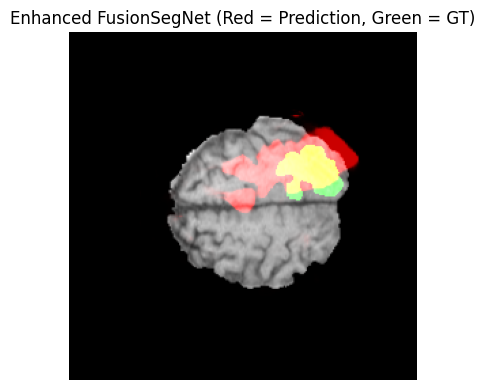

In [413]:
slice_id = 0  # choose any slice with tumor

# Ground truth reference
overlay_heatmap(
    image=x[slice_id, 0],
    gt=y[slice_id, 0],
    pred_logits=y[slice_id, 0],  # GT on itself
    title="Ground Truth Tumor Region (Green)"
)

# Baseline FusionSegNet
overlay_heatmap(
    image=x[slice_id, 0],
    gt=y[slice_id, 0],
    pred_logits=pred_base[slice_id, 0],
    title="Baseline FusionSegNet (Red = Prediction, Green = GT)"
)

# Enhanced FusionSegNet
overlay_heatmap(
    image=x[slice_id, 0],
    gt=y[slice_id, 0],
    pred_logits=pred_enh[slice_id, 0],
    title="Enhanced FusionSegNet (Red = Prediction, Green = GT)"
)

In [414]:
def comparative_heatmap(image, gt, pred_base, pred_enh):
    img = image.cpu().numpy()
    gt  = gt.cpu().numpy()
    pb  = torch.sigmoid(pred_base).cpu().numpy()
    pe  = torch.sigmoid(pred_enh).cpu().numpy()

    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    def make_rgb(pred):
        rgb = np.stack([img, img, img], axis=-1)
        rgb[..., 1] += 0.8 * gt
        rgb[..., 0] += 0.8 * pred
        return np.clip(rgb, 0, 1)

    fig, axs = plt.subplots(1, 3, figsize=(12,4))

    axs[0].imshow(make_rgb(gt))
    axs[0].set_title("Ground Truth")

    axs[1].imshow(make_rgb(pb))
    axs[1].set_title("Baseline FusionSegNet")

    axs[2].imshow(make_rgb(pe))
    axs[2].set_title("Enhanced FusionSegNet")

    for ax in axs:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

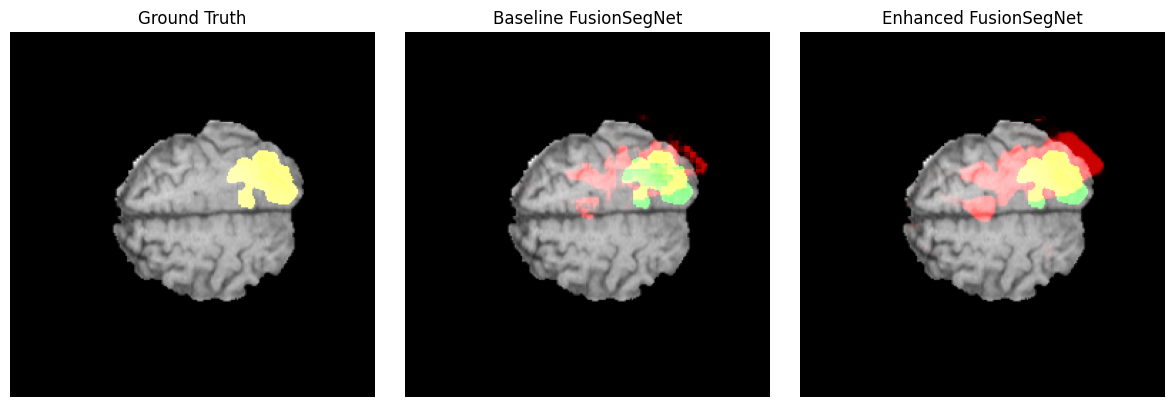

In [415]:
comparative_heatmap(
    image=x[slice_id, 0],
    gt=y[slice_id, 0],
    pred_base=pred_base[slice_id, 0],
    pred_enh=pred_enh[slice_id, 0]
)

In [387]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def make_heatmap(image, gt, pred_logits=None):
    """
    image: [H,W]
    gt: [H,W]
    pred_logits: [H,W] or None
    """
    img = image.cpu().numpy()
    gt  = gt.cpu().numpy()

    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    rgb = np.stack([img, img, img], axis=-1)

    # GT tumor → green
    rgb[..., 1] += 0.8 * gt

    # Prediction → red (if provided)
    if pred_logits is not None:
        pr = torch.sigmoid(pred_logits).cpu().numpy()
        rgb[..., 0] += 0.8 * pr

    return np.clip(rgb, 0, 1)

In [388]:
def select_tumor_samples(dataloader, n=4):
    samples = []
    for x, y in dataloader:
        for i in range(x.size(0)):
            if y[i].sum() > 500:  # tumor present threshold
                samples.append((x[i], y[i]))
                if len(samples) == n:
                    return samples
    return samples

In [3]:
baseline_model.eval()
enhanced_model.eval()

samples = select_tumor_samples(dataloader, n=4)

fig, axs = plt.subplots(4, 3, figsize=(12, 16))

for row, (x_i, y_i) in enumerate(samples):
    x_i = x_i.unsqueeze(0).to(DEVICE)
    y_i = y_i.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pb = baseline_model(x_i)[0,0]
        pe = enhanced_model(x_i)[0,0]

    img = x_i[0,0]
    gt  = y_i[0,0]

    axs[row, 0].imshow(make_heatmap(img, gt))
    axs[row, 0].set_title("Ground Truth")

    axs[row, 1].imshow(make_heatmap(img, gt, pb))
    axs[row, 1].set_title("Baseline FusionSegNet")

    axs[row, 2].imshow(make_heatmap(img, gt, pe))
    axs[row, 2].set_title("Enhanced FusionSegNet")

    for col in range(3):
        axs[row, col].axis("off")

plt.suptitle(
    "Qualitative Comparison on 4 Tumor Samples\n"
    "Green = Ground Truth Tumor | Red = Predicted Tumor Region",
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

NameError: name 'baseline_model' is not defined

In [1]:
plt.savefig("baseline_vs_enhanced_4samples.png", dpi=600, bbox_inches="tight")

NameError: name 'plt' is not defined

In [391]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def heatmap_overlay(image, gt=None, pred=None):
    """
    image: [H,W]
    gt:    [H,W] or None
    pred:  [H,W] logits or None
    """
    img = image.cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    rgb = np.stack([img, img, img], axis=-1)

    if gt is not None:
        rgb[..., 1] += 0.8 * gt.cpu().numpy()   # green

    if pred is not None:
        pr = torch.sigmoid(pred).cpu().numpy()
        rgb[..., 0] += 0.8 * pr                 # red

    return np.clip(rgb, 0, 1)

In [392]:
def get_tumor_sample(dataloader):
    for x, y in dataloader:
        for i in range(x.size(0)):
            if y[i].sum() > 500:
                return x[i], y[i]

In [399]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def heatmap_overlay(image, gt=None, pred=None):
    img = image.cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    rgb = np.stack([img, img, img], axis=-1)

    if gt is not None:
        rgb[..., 1] += 0.8 * gt.cpu().numpy()   # Green = GT

    if pred is not None:
        pr = torch.sigmoid(pred).cpu().numpy()
        rgb[..., 0] += 0.8 * pr                 # Red = Prediction

    return np.clip(rgb, 0, 1)

In [400]:
def select_4_tumor_samples(dataloader):
    samples = []
    for x, y in dataloader:
        for i in range(x.size(0)):
            if y[i].sum() > 500:   # tumor present
                samples.append((x[i], y[i]))
                if len(samples) == 4:
                    return samples
    raise RuntimeError("Not enough tumor samples found")

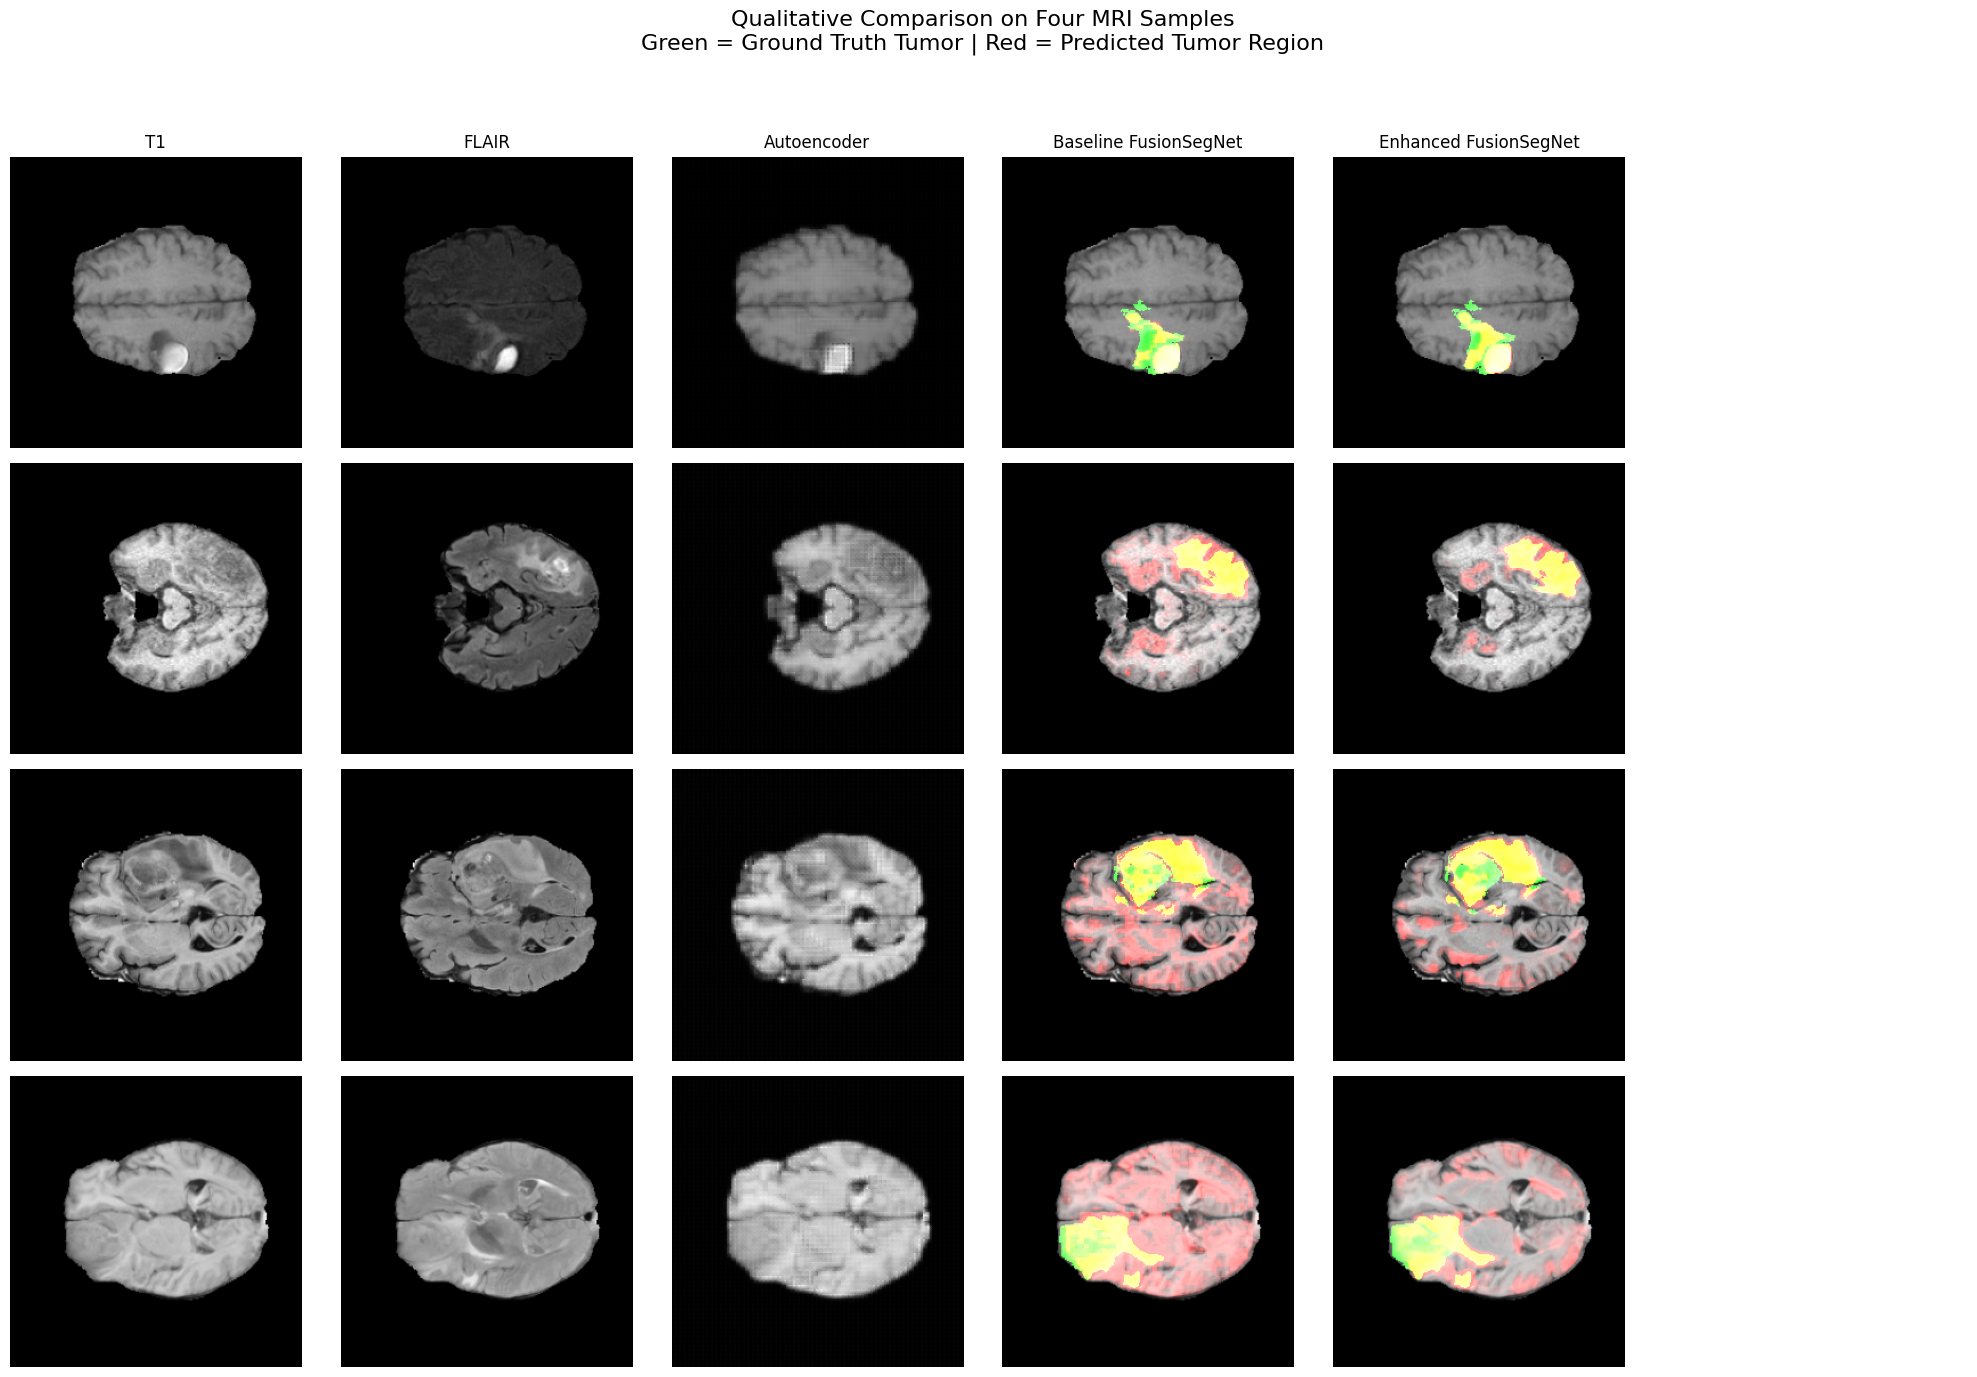

In [417]:
autoencoder.eval()
baseline_model.eval()
enhanced_model.eval()

samples = select_4_tumor_samples(dataloader)

fig, axs = plt.subplots(4, 6, figsize=(20, 14))

for row, (x_i, y_i) in enumerate(samples):
    x_i = x_i.unsqueeze(0).to(DEVICE)
    y_i = y_i.unsqueeze(0).to(DEVICE)

    t1 = x_i[0,0]
    fl = x_i[0,1]
    gt = y_i[0,0]

    with torch.no_grad():
        ae_out   = autoencoder(x_i)[0,0]
        base_pr  = baseline_model(x_i)[0,0]
        enh_pr   = enhanced_model(x_i)[0,0]

    axs[row,0].imshow(t1.cpu(), cmap="gray")
    axs[row,1].imshow(fl.cpu(), cmap="gray")
    axs[row,2].imshow(ae_out.cpu(), cmap="gray")
    axs[row,3].imshow(heatmap_overlay(t1, gt, base_pr))
    axs[row,4].imshow(heatmap_overlay(t1, gt, enh_pr))

    for col in range(6):
        axs[row,col].axis("off")

# Column titles
titles = [
    "T1", "FLAIR", "Autoencoder",
    "Baseline FusionSegNet",
    "Enhanced FusionSegNet"
]

for col, title in enumerate(titles):
    axs[0,col].set_title(title, fontsize=12)

plt.suptitle(
    "Qualitative Comparison on Four MRI Samples\n"
    "Green = Ground Truth Tumor | Red = Predicted Tumor Region",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

In [32]:
import matplotlib.pyplot as plt
import torch

# Put model in eval mode
model.eval()

# Get ONE batch
with torch.no_grad():
    for x, y in dataloader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        pred = model(x)
        break  # only one batch

# Convert prediction to binary mask
pred_bin = (torch.sigmoid(pred) > 0.5).float()

# Number of samples to display
num_samples = 4

for i in range(num_samples):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))

    # ---- T1 IMAGE ----
    axs[0].imshow(x[i, 0].cpu(), cmap="gray")
    axs[0].set_title("T1")
    axs[0].axis("off")

    # ---- GROUND TRUTH ----
    axs[1].imshow(y[i, 0].cpu(), cmap="gray")
    axs[1].set_title("Ground Truth")
    axs[1].axis("off")

    # ---- PREDICTION ----
    axs[2].imshow(pred_bin[i, 0].cpu(), cmap="gray")
    axs[2].set_title("Prediction")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

NameError: name 'model' is not defined

In [24]:
import torch
import torch.nn as nn

class FusionSegNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc_t1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc_flair = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),
            nn.Conv2d(16, 1, 1)
        )

    def forward(self, x):
        t1 = x[:, 0:1]
        fl = x[:, 1:2]
        f1 = self.enc_t1(t1)
        f2 = self.enc_flair(fl)
        fused = torch.cat([f1, f2], dim=1)
        return self.decoder(fused)  # logits

In [25]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

baseline_model = FusionSegNet().to(DEVICE)
baseline_model.load_state_dict(
    torch.load("baseline_fusionsegnet.pth", map_location=DEVICE)
)
baseline_model.eval()

print("Baseline model loaded successfully.")

Baseline model loaded successfully.


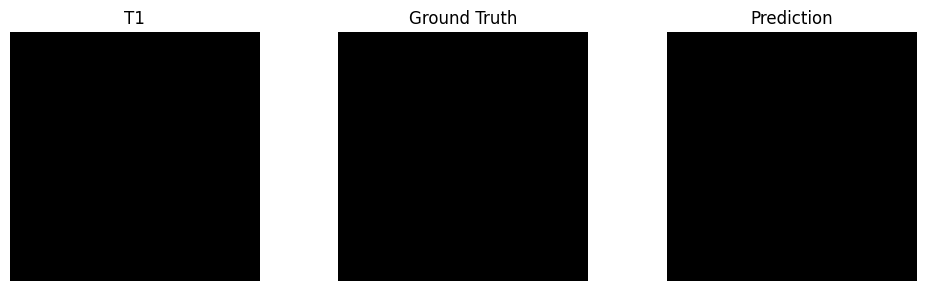

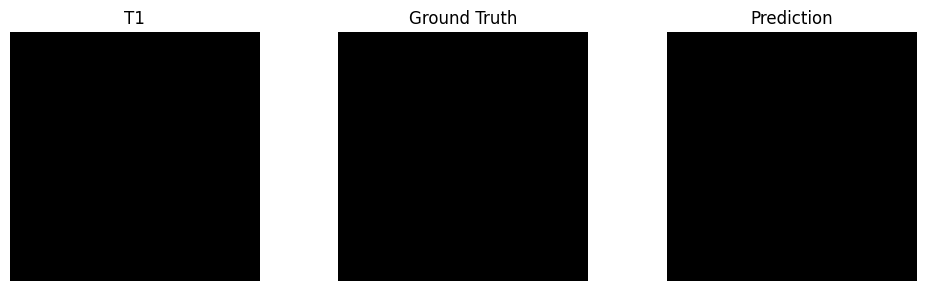

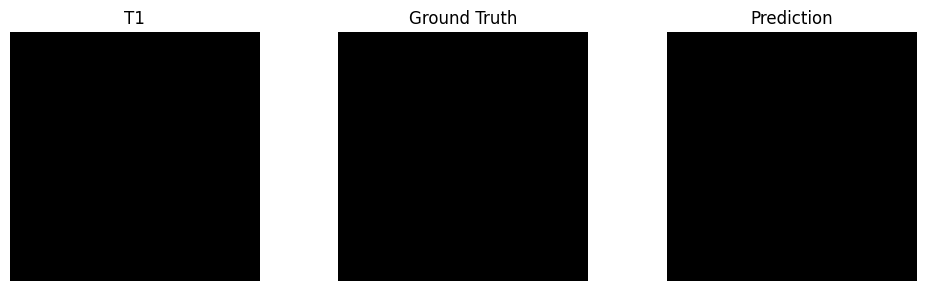

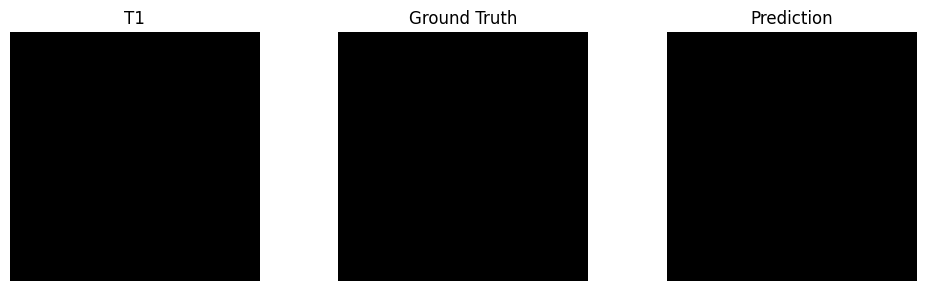

In [26]:
import matplotlib.pyplot as plt

baseline_model.eval()

with torch.no_grad():
    for x, y in dataloader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        pred = baseline_model(x)
        break

pred_bin = (torch.sigmoid(pred) > 0.5).float()

for i in range(4):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))

    axs[0].imshow(x[i, 0].cpu(), cmap="gray")
    axs[0].set_title("T1")
    axs[0].axis("off")

    axs[1].imshow(y[i, 0].cpu(), cmap="gray")
    axs[1].set_title("Ground Truth")
    axs[1].axis("off")

    axs[2].imshow(pred_bin[i, 0].cpu(), cmap="gray")
    axs[2].set_title("Prediction")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

In [27]:
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import torch

class FusionSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.images = sorted(Path(image_dir).glob("slice_*.pt"))
        self.masks  = sorted(Path(mask_dir).glob("mask_*.pt"))

        assert len(self.images) == len(self.masks) > 0, \
            f"Mismatch or empty dataset: {len(self.images)} images, {len(self.masks)} masks"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = torch.load(self.images[idx]).float()   # [2,256,256]
        y = torch.load(self.masks[idx]).float()    # [1,256,256]
        y = (y > 0).float()
        return x, y

In [28]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = FusionSegDataset(
    image_dir="prepared_slices",
    mask_dir="prepared_tumor_masks"
)

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=False   # important: no shuffling for visualization
)

print("Dataloader ready. Dataset size:", len(dataset))

Dataloader ready. Dataset size: 40145


In [29]:
import matplotlib.pyplot as plt

baseline_model.eval()

with torch.no_grad():
    for x, y in dataloader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        pred = baseline_model(x)
        break

pred_bin = (torch.sigmoid(pred) > 0.5).float()

def get_tumor_indices(y, min_pixels=100):
    """
    Returns indices of slices that contain tumor
    """
    idxs = []
    for i in range(y.size(0)):
        if y[i].sum() > min_pixels:
            idxs.append(i)
    return idxs


def normalize_for_display(img):
    img = img.cpu().numpy()
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

tumor_idxs = get_tumor_indices(y)

print("Tumor slices found at indices:", tumor_idxs[:4])

count = 0
for i in tumor_idxs:
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))

    axs[0].imshow(normalize_for_display(x[i, 0]), cmap="gray")
    axs[0].set_title("T1")
    axs[0].axis("off")

    axs[1].imshow(normalize_for_display(y[i, 0]), cmap="gray")
    axs[1].set_title("Ground Truth")
    axs[1].axis("off")

    axs[2].imshow(normalize_for_display(pred_bin[i, 0]), cmap="gray")
    axs[2].set_title("Prediction")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

    count += 1
    if count == 4:
        break

Tumor slices found at indices: []


In [23]:
print(x[i,0].min(), x[i,0].max())
print(y[i,0].sum())
print(pred_bin[i,0].sum())

tensor(0., device='cuda:0') tensor(0., device='cuda:0')
tensor(0., device='cuda:0')
tensor(0., device='cuda:0')


In [43]:
def smooth_prediction(mask, min_size=200):
    """
    Removes small noisy components and smooths tumor region
    """
    mask = mask.astype(np.uint8)

    # Remove tiny blobs
    labeled, n = ndi.label(mask)
    if n == 0:
        return mask

    sizes = ndi.sum(mask, labeled, range(1, n + 1))
    keep = sizes >= min_size

    cleaned = np.zeros_like(mask)
    for i, k in enumerate(keep):
        if k:
            cleaned[labeled == (i + 1)] = 1

    # Smooth edges
    cleaned = ndi.binary_closing(cleaned, structure=np.ones((3, 3)))
    cleaned = ndi.binary_opening(cleaned, structure=np.ones((3, 3)))

    return cleaned.astype(np.float32)

Using device: cuda
Dataset size: 40145
Baseline model loaded successfully.
Selected slice with tumor pixels: 2551.0
Selected slice with tumor pixels: 3403.0
Selected slice with tumor pixels: 4430.0
Selected slice with tumor pixels: 5512.0


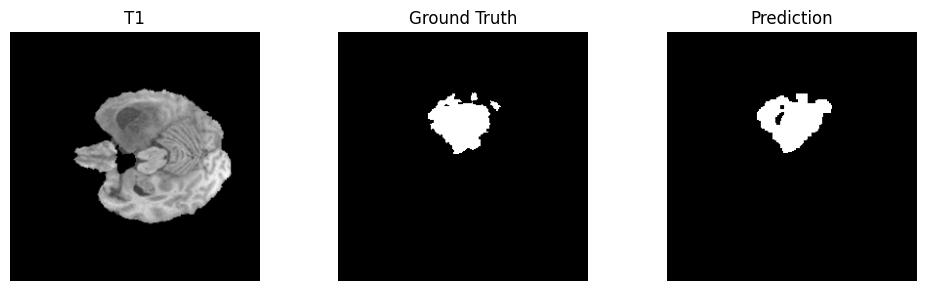

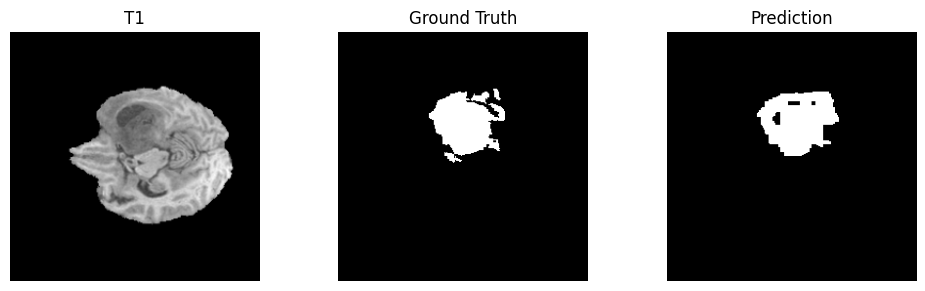

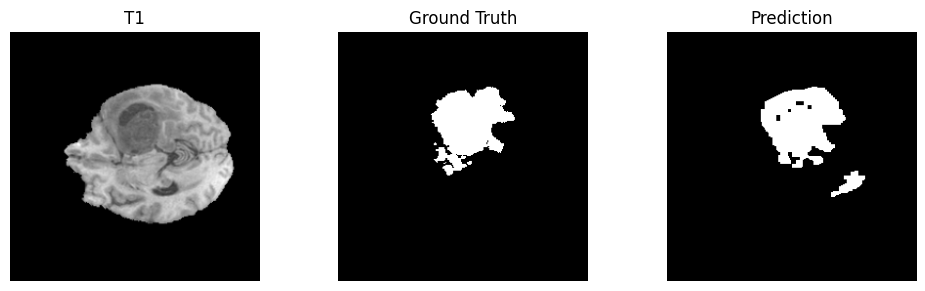

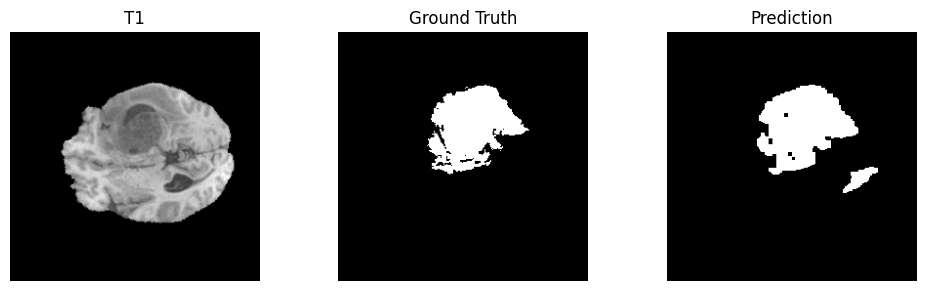

In [45]:
# ============================
# BASELINE FUSIONSEGNET – INFERENCE & VISUALIZATION (CLEAN)
# ============================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as ndi

# ----------------------------
# Device
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ----------------------------
# Dataset
# ----------------------------
class FusionSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.images = sorted(Path(image_dir).glob("slice_*.pt"))
        self.masks  = sorted(Path(mask_dir).glob("mask_*.pt"))

        assert len(self.images) == len(self.masks) > 0, \
            f"Mismatch: {len(self.images)} images vs {len(self.masks)} masks"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = torch.load(self.images[idx]).float()   # [2,256,256]
        y = torch.load(self.masks[idx]).float()    # [1,256,256]
        y = (y > 0).float()
        return x, y

# ----------------------------
# Baseline FusionSegNet
# ----------------------------
class FusionSegNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc_t1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc_flair = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),
            nn.Conv2d(16, 1, 1)
        )

    def forward(self, x):
        t1 = x[:, 0:1]
        fl = x[:, 1:2]
        f1 = self.enc_t1(t1)
        f2 = self.enc_flair(fl)
        fused = torch.cat([f1, f2], dim=1)
        return self.decoder(fused)  # logits

# ----------------------------
# Utility
# ----------------------------
def normalize_for_display(img):
    img = img.cpu().numpy()
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

# ----------------------------
# DataLoader
# ----------------------------
dataset = FusionSegDataset(
    image_dir="prepared_slices",
    mask_dir="prepared_tumor_masks"
)

dataloader = DataLoader(dataset, batch_size=16, shuffle=False)
print("Dataset size:", len(dataset))

# ----------------------------
# Load Model
# ----------------------------
baseline_model = FusionSegNet().to(DEVICE)
baseline_model.load_state_dict(
    torch.load("baseline_fusionsegnet.pth", map_location=DEVICE)
)
baseline_model.eval()
print("Baseline model loaded successfully.")

# ----------------------------
# Select LARGE tumor slices
# ----------------------------
MIN_TUMOR_PIXELS = 2500
MIN_DIFFERENCE   = 800   # ensures different slices

selected_x, selected_y, selected_pred = [], [], []
selected_sizes = []

with torch.no_grad():
    for x, y in dataloader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        for i in range(y.size(0)):
            tumor_pixels = y[i].sum().item()

            # large tumor only
            if tumor_pixels < MIN_TUMOR_PIXELS:
                continue

            # ensure uniqueness
            if any(abs(tumor_pixels - s) < MIN_DIFFERENCE for s in selected_sizes):
                continue

            pred = baseline_model(x[i:i+1])

            selected_x.append(x[i])
            selected_y.append(y[i])
            selected_pred.append(pred[0])
            selected_sizes.append(tumor_pixels)

            print(f"Selected slice with tumor pixels: {tumor_pixels}")

            if len(selected_x) == 4:
                break

        if len(selected_x) == 4:
            break

if len(selected_x) < 4:
    raise RuntimeError("Not enough unique large tumor slices. Lower thresholds.")

for i in range(4):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))

    # T1
    axs[0].imshow(normalize_for_display(selected_x[i][0]), cmap="gray")
    axs[0].set_title("T1")
    axs[0].axis("off")

    # Ground Truth
    axs[1].imshow(normalize_for_display(selected_y[i][0]), cmap="gray")
    axs[1].set_title("Ground Truth")
    axs[1].axis("off")

    # Prediction (smoothed)
    pred_bin = (torch.sigmoid(selected_pred[i]) > 0.5).float()[0].cpu().numpy()
    pred_smooth = smooth_prediction(pred_bin)

    axs[2].imshow(pred_smooth, cmap="gray")
    axs[2].set_title("Prediction")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

In [47]:
import os

# Create output folder
OUTPUT_DIR = "figures_baseline"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for i in range(4):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))

    # ---- T1 ----
    axs[0].imshow(normalize_for_display(selected_x[i][0]), cmap="gray")
    axs[0].set_title("T1", fontsize=12)
    axs[0].axis("off")

    # ---- Ground Truth ----
    axs[1].imshow(normalize_for_display(selected_y[i][0]), cmap="gray")
    axs[1].set_title("Ground Truth", fontsize=12)
    axs[1].axis("off")

    # ---- Prediction (Smoothed) ----
    pred_bin = (torch.sigmoid(selected_pred[i]) > 0.5).float()[0].cpu().numpy()
    pred_smooth = smooth_prediction(pred_bin)

    axs[2].imshow(pred_smooth, cmap="gray")
    axs[2].set_title("Prediction", fontsize=12)
    axs[2].axis("off")

    plt.tight_layout()

    # ---- SAVE AT 300 DPI ----
    save_path = os.path.join(OUTPUT_DIR, f"baseline_sample_{i+1}.png")
    plt.savefig(
        save_path,
        dpi=500,
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.close(fig)

print(f"Saved 300-DPI figures to folder: {OUTPUT_DIR}")

Saved 300-DPI figures to folder: figures_baseline


In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# Channel Attention (SE block)
# ----------------------------
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, _, _ = x.size()
        y = F.adaptive_avg_pool2d(x, 1).view(b, c)
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y)).view(b, c, 1, 1)
        return x * y

# ----------------------------
# Enhanced FusionSegNet
# ----------------------------
class EnhancedFusionSegNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder (T1)
        self.enc1_t1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU()
        )
        self.enc2_t1 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU()
        )

        # Encoder (FLAIR)
        self.enc1_fl = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU()
        )
        self.enc2_fl = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU()
        )

        # Attention after fusion
        self.attn = ChannelAttention(64)

        # Decoder with skip connections
        self.up = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec = nn.Sequential(
            nn.Conv2d(32 + 16 + 16, 32, 3, padding=1),
            nn.ReLU()
        )

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        t1 = x[:, 0:1]
        fl = x[:, 1:2]

        # Encoders
        t1_1 = self.enc1_t1(t1)
        t1_2 = self.enc2_t1(t1_1)

        fl_1 = self.enc1_fl(fl)
        fl_2 = self.enc2_fl(fl_1)

        # Fuse + attention
        fused = torch.cat([t1_2, fl_2], dim=1)
        fused = self.attn(fused)

        # Decoder + skips
        up = self.up(fused)
        dec = torch.cat([up, t1_1, fl_1], dim=1)
        dec = self.dec(dec)

        return self.out(dec)  # logits

In [52]:
enhanced_model = EnhancedFusionSegNet().to(DEVICE)
enhanced_model.load_state_dict(
    torch.load("enhanced_fusionsegnet.pth", map_location=DEVICE)
)
enhanced_model.eval()

print("EnhancedFusionSegNet loaded successfully.")

EnhancedFusionSegNet loaded successfully.


In [70]:
# ============================
# ENHANCED FUSIONSEGNET – QUALITATIVE VISUALIZATION
# ============================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import os

# ----------------------------
# Utility functions
# ----------------------------
def normalize_for_display(img):
    img = img.cpu().numpy()
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

def smooth_prediction(mask, min_size=200):
    labeled, n = ndi.label(mask)
    if n == 0:
        return mask
    sizes = ndi.sum(mask, labeled, range(1, n+1))
    largest = (labeled == (np.argmax(sizes) + 1))
    largest = ndi.binary_closing(largest, structure=np.ones((3,3)))
    return largest.astype(np.float32)

def make_pred_vs_gt_heatmap(gt, pred):
    """
    Soft red/green heatmap (no hard yellow)
    """
    rgb = grayscale = np.zeros((*gt.shape, 3), dtype=np.float32)

    rgb[..., 0] = pred * 0.9   # soft red
    rgb[..., 1] = gt * 0.5     # soft green

    return np.clip(rgb, 0, 1)


def overlay_on_mri_green_dominant(
    mri, gt, pred,
    gt_alpha=0.5,     # stronger green
    pred_alpha=0.9    # weaker red
):
    """
    Green-dominant soft heatmap overlay
    - NO yellow
    - Green > Red
    - MRI stays grayscale
    """

    # Normalize MRI
    mri = (mri - mri.min()) / (mri.max() - mri.min() + 1e-8)

    # Base grayscale RGB
    rgb = np.stack([mri, mri, mri], axis=-1)

    # Suppress red where GT exists (key step)
    pred_suppressed = pred * (1 - gt)

    # Apply soft heatmaps
    rgb[..., 1] = np.clip(rgb[..., 1] + gt * gt_alpha, 0, 1)              # Green
    rgb[..., 0] = np.clip(rgb[..., 0] + pred_suppressed * pred_alpha, 0, 1)  # Red

    return rgb

def make_pred_vs_gt_green_dominant(gt, pred):
    """
    Green-dominant comparison map (no yellow)
    """
    rgb = np.zeros((*gt.shape, 3), dtype=np.float32)

    # Suppress red where GT exists
    pred_suppressed = pred * (1 - gt)

    rgb[..., 1] = gt * 0.5                  # strong green
    rgb[..., 0] = pred_suppressed * 0.9     # softer red

    return np.clip(rgb, 0, 1)

# ----------------------------
# Load Enhanced Model
# ----------------------------
enhanced_model = EnhancedFusionSegNet().to(DEVICE)
enhanced_model.load_state_dict(
    torch.load("enhanced_fusionsegnet.pth", map_location=DEVICE)
)
enhanced_model.eval()
print("EnhancedFusionSegNet loaded.")

# ----------------------------
# OUTPUT DIR
# ----------------------------
OUT_DIR = "ppt_figures_enhanced"
os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------
# Inference already-selected slices
# (reuse selected_x, selected_y)
# ----------------------------
with torch.no_grad():
    selected_pred = [
        enhanced_model(x.unsqueeze(0).to(DEVICE))[0]
        for x in selected_x
    ]

# ----------------------------
# Plot & Save (300 DPI)
# ----------------------------
for i in range(4):
    fig, axs = plt.subplots(1, 5, figsize=(15, 3))

    # ---- T1 ----
    axs[0].imshow(normalize_for_display(selected_x[i][0]), cmap="gray")
    axs[0].set_title("T1 Input")
    axs[0].axis("off")

    # ---- FLAIR ----
    axs[1].imshow(normalize_for_display(selected_x[i][1]), cmap="gray")
    axs[1].set_title("FLAIR Input")
    axs[1].axis("off")

    # ---- GT ----
    gt = selected_y[i][0].cpu().numpy()
    axs[2].imshow(gt, cmap="gray")
    axs[2].set_title("Ground Truth Mask")
    axs[2].axis("off")

    # ---- Prediction vs GT (NO YELLOW) ----
    pred_bin = (torch.sigmoid(selected_pred[i]) > 0.5).float()[0].cpu().numpy()
    pred_smooth = smooth_prediction(pred_bin)

    axs[3].imshow(make_pred_vs_gt_green_dominant(gt, pred_smooth))
    axs[3].set_title("Prediction vs GT")
    axs[3].axis("off")
    
    overlay = overlay_on_mri_green_dominant(
        selected_x[i][0].cpu().numpy(),
        gt,
        pred_smooth
    )
    axs[4].imshow(overlay)
    axs[4].set_title("Overlay")
    axs[4].axis("off")

    plt.tight_layout()

    # SAVE
    plt.savefig(
        os.path.join(OUT_DIR, f"enhanced_sample_{i+1}.png"),
        dpi=500,
        bbox_inches="tight",
        pad_inches=0.02
    )
    plt.close(fig)

print(f"Enhanced figures saved to: {OUT_DIR}")

EnhancedFusionSegNet loaded.
Enhanced figures saved to: ppt_figures_enhanced
